In [64]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Namo\Downloads\credit_risk.csv")
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [67]:
df=pd.read_csv(r"C:\Users\Namo\Downloads\credit_risk.csv")

In [68]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


# 2.Load Dataset

In [69]:
print("First 5 Rows")
print(df.head())

First 5 Rows
                status  duration                            credit_history  \
0         ... < 100 DM         6   critical account/other credits existing   
1    0 <= ... < 200 DM        48  existing credits paid back duly till now   
2  no checking account        12   critical account/other credits existing   
3         ... < 100 DM        42  existing credits paid back duly till now   
4         ... < 100 DM        24           delay in paying off in the past   

               purpose  amount                     savings  \
0  domestic appliances    1169  unknown/no savings account   
1  domestic appliances    5951                ... < 100 DM   
2           retraining    2096                ... < 100 DM   
3     radio/television    7882                ... < 100 DM   
4            car (new)    4870                ... < 100 DM   

  employment_duration  installment_rate                  personal_status_sex  \
0      ... >= 7 years                 4                        ma

In [70]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(1000, 21)


In [71]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [72]:
print(df.isnull().sum())

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


In [73]:
print(df.describe())

          duration        amount  installment_rate  present_residence  \
count  1000.000000   1000.000000       1000.000000        1000.000000   
mean     20.903000   3271.258000          2.973000           2.845000   
std      12.058814   2822.736876          1.118715           1.103718   
min       4.000000    250.000000          1.000000           1.000000   
25%      12.000000   1365.500000          2.000000           2.000000   
50%      18.000000   2319.500000          3.000000           3.000000   
75%      24.000000   3972.250000          4.000000           4.000000   
max      72.000000  18424.000000          4.000000           4.000000   

               age  number_credits  people_liable  credit_risk  
count  1000.000000     1000.000000    1000.000000  1000.000000  
mean     35.546000        1.407000       1.155000     0.700000  
std      11.375469        0.577654       0.362086     0.458487  
min      19.000000        1.000000       1.000000     0.000000  
25%      27.00000

#  4.Data Preprocessing

In [74]:
#Encode Categorical Columns

le=LabelEncoder()

for col in df.columns:
    if df[col].dtype=='object':
     df[col]=le.fit_transform(df[col])

In [75]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,0,6,1,3,1169,4,1,4,3,2,...,2,67,1,1,2,1,1,1,1,1
1,2,48,3,3,5951,0,2,2,0,2,...,2,22,1,1,1,1,1,0,1,0
2,3,12,1,9,2096,0,3,2,3,2,...,2,49,1,1,1,3,2,0,1,1
3,0,42,3,7,7882,0,3,2,3,1,...,0,45,1,0,1,1,2,0,1,1
4,0,24,2,1,4870,0,2,3,3,2,...,3,53,1,0,2,1,2,0,1,0


# 5.Exploratory Data Analysis

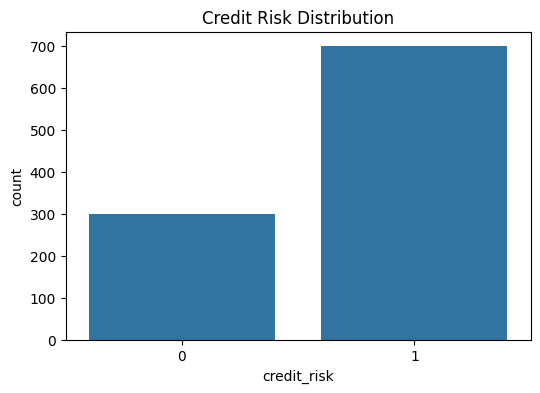

In [76]:
# Credit Risk Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='credit_risk',data=df)
plt.title("Credit Risk Distribution")
plt.show()

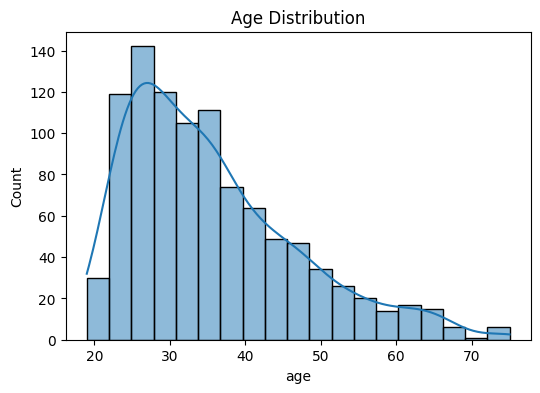

In [77]:
#Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['age'],kde=True)
plt.title("Age Distribution")
plt.show()

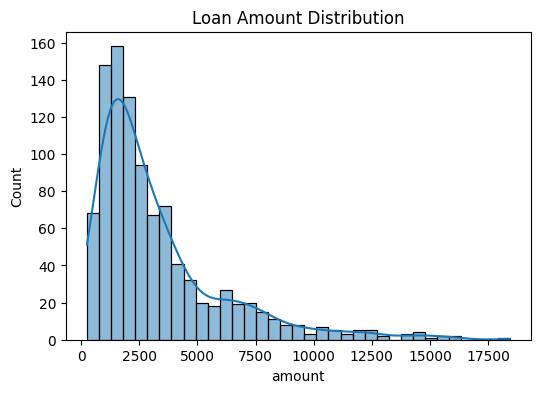

In [78]:
#Loan Amount Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['amount'],kde=True)
plt.title("Loan Amount Distribution")
plt.show()

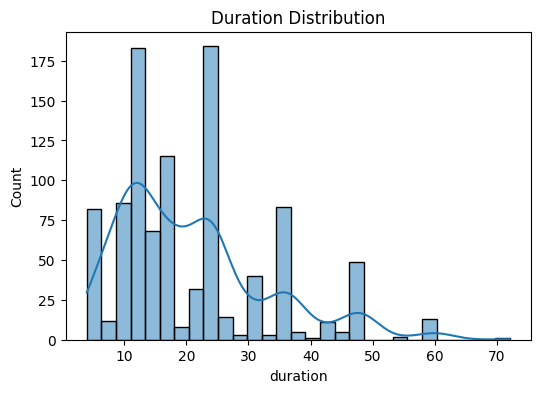

In [79]:
#Duration Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['duration'],kde=True)
plt.title("Duration Distribution")
plt.show()

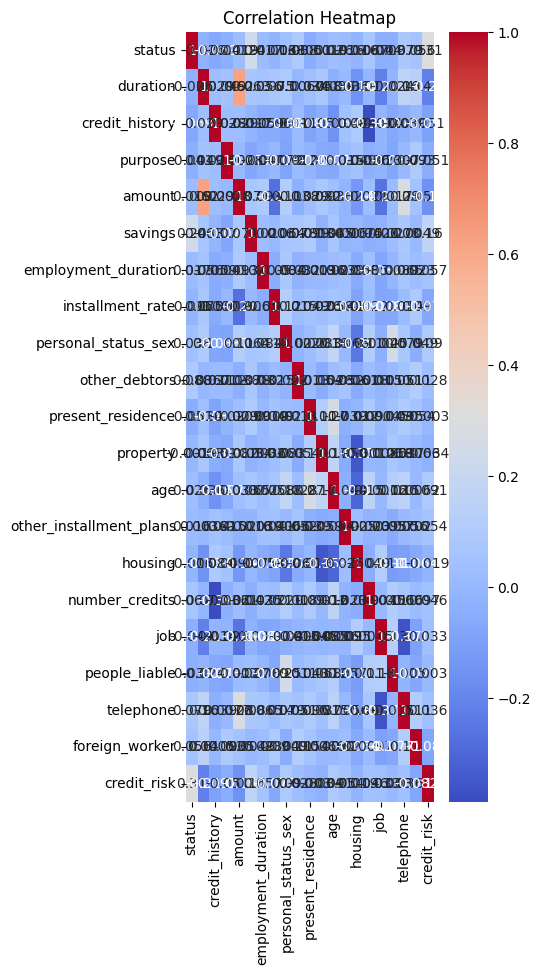

In [80]:
#Correlation Heatmap

plt.figure(figsize=(4,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 6.Features And Target

In [81]:
X=df.drop('credit_risk',axis=1)
y=df['credit_risk']

In [82]:
print(df.columns)

Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
       'employment_duration', 'installment_rate', 'personal_status_sex',
       'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='object')


# 7.Train Test Split

In [83]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 8. Decision Tree Model

In [84]:
dt_model=DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train,y_train)
dt_pred=dt_model.predict(X_test)

# 9.Decision Tree Evaluation


Decision  Tree Accuracy:
0.725

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.63      0.57        59
           1       0.83      0.77      0.80       141

    accuracy                           0.72       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200



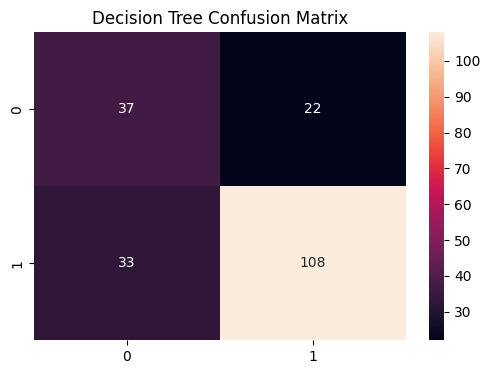

In [85]:
print("\nDecision  Tree Accuracy:")
print(accuracy_score(y_test,dt_pred))

print("\nClassification Report:")
print(classification_report(y_test,dt_pred))

cm=confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# 10. Feature Importance


Feature Importance
                    Feature  Importance
4                    amount    0.185489
0                    status    0.122354
12                      age    0.110280
3                   purpose    0.091245
1                  duration    0.082376
2            credit_history    0.065856
10        present_residence    0.061071
5                   savings    0.035335
7          installment_rate    0.029813
8       personal_status_sex    0.029745
6       employment_duration    0.029032
13  other_installment_plans    0.027253
11                 property    0.026519
18                telephone    0.026171
16                      job    0.022521
15           number_credits    0.015956
9             other_debtors    0.014140
14                  housing    0.012658
19           foreign_worker    0.009261
17            people_liable    0.002923


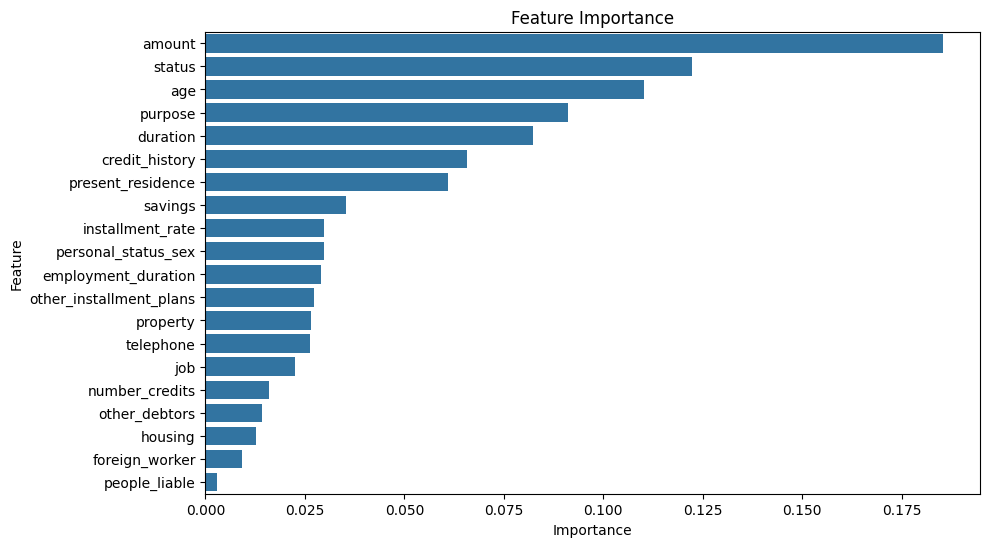

In [86]:
importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':dt_model.feature_importances_})

importance=importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()


# 11. Random Forest Model

In [87]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)

# 12.Random Forest Evaluation


Random Forestt Accuracy:
0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.42      0.52        59
           1       0.79      0.91      0.85       141

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.76      0.77      0.75       200



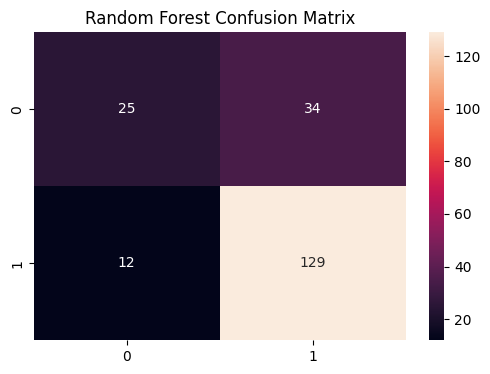

In [88]:
print("\nRandom Forestt Accuracy:")
print(accuracy_score(y_test,rf_pred))

print("\nClassification Report:")
print(classification_report(y_test,rf_pred))

rf_cm=confusion_matrix(
    y_test,
    rf_pred
)
plt.figure(figsize=(6,4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d'
)
plt.title("Random Forest Confusion Matrix")
plt.show()

# 13. Model Comparison

In [89]:
dt_accuracy=accuracy_score(
    y_test,
    dt_pred
)

rf_accuracy=accuracy_score(
    y_test,
    rf_pred
)
comparison=pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        dt_accuracy,
        rf_accuracy
    ]
    })
print("\nModel Comparison")
print(comparison)

                        


Model Comparison
           Model  Accuracy
0  Decision Tree     0.725
1  Random Forest     0.770


# 14. Conclusion

#
This project developed a machine-learning based Credit Risk Assessment system.
That predicts whether an applicant is likely to be a good or bad credit risk.

Data Preprocessing ,exploratory Data analysis (EDA) and classification models were implemented on the dataset.
Decison Tree and Random Forest Classifiers were trained and evaluated using accuracy,confusion matrix  and classification Reports.

Based on the model comparison,the model with the higher accuracy can be considered as more effective for predicting credit risk.
Such models can help financial institutions make informed decisions regarding lending and reduced potential financial losses.

Among the evaluated models,the Random Forest Classifier achieved the highest accuracy (77%) and was selected as the best performing model for credit risk prediction.